<a href="https://colab.research.google.com/github/tarasovEgor/DeepLearningKurs/blob/main/src/lab_4/VAE_lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Лабораторная работа 4.**

---

## Генерация данных с использованием вариационных автоэнкодеров (VAE).

---

## **Цель работы:** изучить принципы работы вариационных автокодировщиков (VAE) и их применение для генерации новых данных. Также будет проведен анализ латентного пространства и исследованы возможности его интерпретации.


### 0. Init steps

---

#### Импорты библиотек и настройка среды:

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Lambda, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Подготовка данных

#### 1.1 Загрузка и нормализация MNIST:

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Нормализация пикселей из диапазона [0, 255] в диапазон [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Добавляем размерность канала: было (28, 28), стало (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"Форма тренировочных данных: {x_train.shape}")
print(f"Форма тестовых данных: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Форма тренировочных данных: (60000, 28, 28, 1)
Форма тестовых данных: (10000, 28, 28, 1)


#### 1.2. Проверка структуры данных:

In [3]:
print(f"Размер тренировочного набора: {x_train.shape}, метки: {y_train.shape}")
print(f"Размер тестового набора: {x_test.shape}, метки: {y_test.shape}")

Размер тренировочного набора: (60000, 28, 28, 1), метки: (60000,)
Размер тестового набора: (10000, 28, 28, 1), метки: (10000,)


#### 1.3. Визуализация первых изображений:

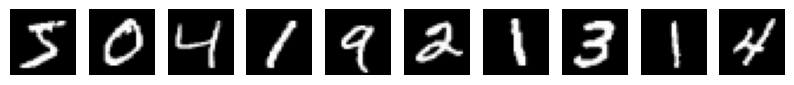

In [4]:
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

#### 1.4. Распределение классов:

In [5]:
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Распределение классов в тренировочном наборе:")
print(dict(zip(unique_train, counts_train)))

print("\nРаспределение классов в тестовом наборе:")
print(dict(zip(unique_test, counts_test)))

Распределение классов в тренировочном наборе:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}

Распределение классов в тестовом наборе:
{np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


#### 1.5. Аугментация данных:

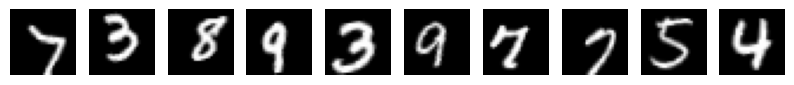

In [7]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train)

augmented_images, augmented_labels = next(
    datagen.flow(x_train, y_train, batch_size=10)
)

plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(augmented_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

#### 1.6 Преобразование изображений в одномерный массив для PCA:

In [8]:
# Преобразование изображений 28x28x1 в одномерные векторы длиной 784
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

print(f"Размер тренировочных данных после преобразования: {x_train_flat.shape}")
print(f"Размер тестовых данных после преобразования: {x_test_flat.shape}")

Размер тренировочных данных после преобразования: (60000, 784)
Размер тестовых данных после преобразования: (10000, 784)


#### 1.7 Cтатистический анализ пикселей:

In [9]:
print(f"Минимум: {x_train.min()}")
print(f"Максимум: {x_train.max()}")
print(f"Среднее: {x_train.mean():.4f}")
print(f"Стандартное отклонение: {x_train.std():.4f}")

Минимум: 0.0
Максимум: 1.0
Среднее: 0.1307
Стандартное отклонение: 0.3081


#### 1.8 Добавление гауссовского шума:

In [10]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Ограничиваем значения пикселей диапазоном [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print(f"Форма шумных тренировочных данных: {x_train_noisy.shape}")
print(f"Форма шумных тестовых данных: {x_test_noisy.shape}")

Форма шумных тренировочных данных: (60000, 28, 28, 1)
Форма шумных тестовых данных: (10000, 28, 28, 1)


#### 1.9 Bизуализация зашумленных изображений:

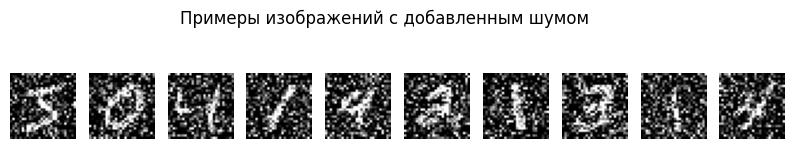

In [11]:
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Примеры изображений с добавленным шумом")
plt.show()

#### 1.10 Создание поднабора данных:

In [13]:
small_x_train = x_train[:1000]
small_y_train = y_train[:1000]

print(f"Размер небольшого поднабора изображений: {small_x_train.shape}")
print(f"Размер небольшого поднабора меток: {small_y_train.shape}")

Размер небольшого поднабора изображений: (1000, 28, 28, 1)
Размер небольшого поднабора меток: (1000,)


----

#### 1.11 Ответы на вопросы анализа к шагу 1:

- **Как распределение классов влияет на обучение модели?**
Если одних цифр в данных намного больше, чем других, модель может лучше восстанавливать и генерировать именно эти классы. В MNIST распределение классов достаточно сбалансировано, поэтому модель получает примеры всех цифр примерно равномерно.

- **Какие преобразования данных могут улучшить генерацию изображений?**
Для MNIST полезны небольшие повороты, сдвиги, масштабирование и умеренный zoom. Слишком сильные преобразования могут искажать цифры и ухудшать обучение.

- **Как добавление шума может помочь в обучении устойчивых моделей?**
Шум заставляет модель выделять устойчивые признаки изображения, например форму цифры, а не запоминать отдельные пиксели. Это помогает автоэнкодеру лучше обобщать данные.

---

### 2. Реализация классического автокодировщика AE


#### 2.1 Создание архитектуры AE:

In [14]:
# Размер латентного пространства классического AE
ae_latent_dim = 64

# Входное изображение
input_img = Input(shape=(28, 28, 1))

# Энкодер: изображение -> вектор признаков
x = Flatten()(input_img)
encoded = Dense(ae_latent_dim, activation="relu", name="ae_latent_vector")(x)

# Декодер: вектор признаков -> восстановленное изображение
x = Dense(28 * 28, activation="sigmoid")(encoded)
decoded = Reshape((28, 28, 1))(x)

# Полная модель автокодировщика
autoencoder = Model(input_img, decoded, name="Classic_Autoencoder")

# Отдельная модель энкодера пригодится позже для анализа латентного пространства
encoder_ae = Model(input_img, encoded, name="AE_Encoder")

autoencoder.compile(
    optimizer=Adam(),
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "Classic_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_latent_vector (Dense)        │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.2 Реконструкция до обучения:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


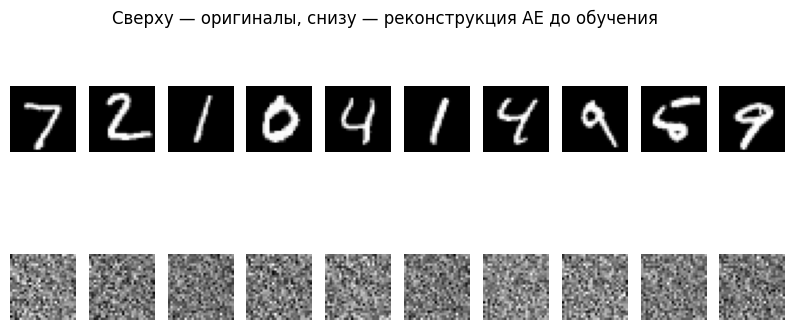

In [15]:
# Реконструкция до обучения, когда веса модели еще случайные
decoded_imgs_before = autoencoder.predict(x_test[:10])

plt.figure(figsize=(10, 4))

for i in range(10):
    # Оригинал
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Реконструкция до обучения
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(decoded_imgs_before[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Сверху - оригиналы, снизу - реконструкция AE до обучения")
plt.show()

#### 2.3 Обучение AE:

In [16]:
history_ae = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2519 - val_loss: 0.1667
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1486 - val_loss: 0.1323
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1228 - val_loss: 0.1137
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1079 - val_loss: 0.1025
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0983 - val_loss: 0.0948
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0916 - val_loss: 0.0894
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0868 - val_loss: 0.0855
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0833 - val_loss: 0.0824
Epoch 9/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0807 - val_loss: 0.0802
Epoch 10/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0789 - val_loss: 0.0787


#### 2.4 График функции потерь AE:

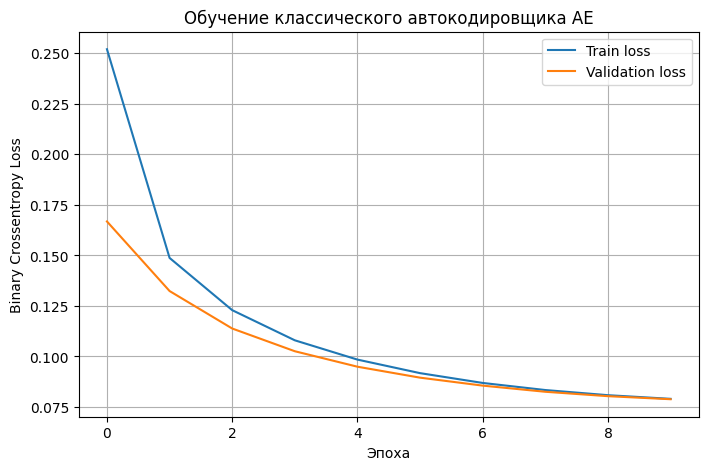

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history_ae.history["loss"], label="Train loss")
plt.plot(history_ae.history["val_loss"], label="Validation loss")

plt.title("Обучение классического автокодировщика AE")
plt.xlabel("Эпоха")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid()
plt.show()

#### 2.5 Реконструкция после обучения:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


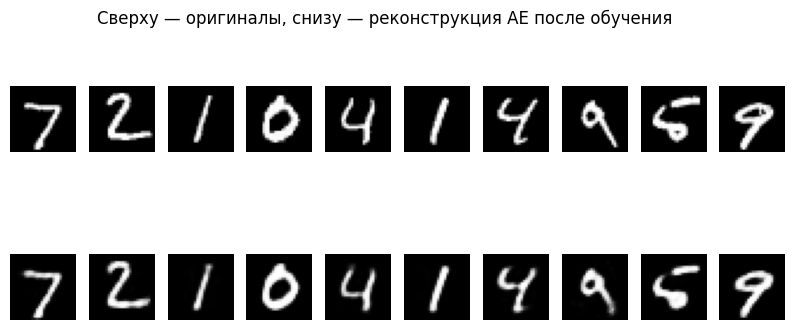

In [18]:
decoded_imgs_after = autoencoder.predict(x_test[:10])

plt.figure(figsize=(10, 4))

for i in range(10):
    # Оригинал
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Реконструкция после обучения
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(decoded_imgs_after[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Сверху — оригиналы, снизу — реконструкция AE после обучения")
plt.show()

#### 2.6 Сравнение до и после обучения в одной визуализации:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


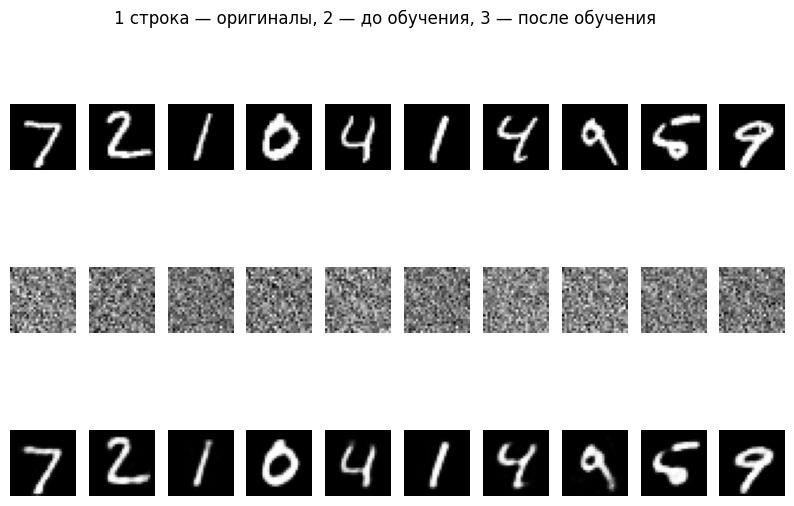

In [19]:
decoded_imgs_after = autoencoder.predict(x_test[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    # Оригинал
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # До обучения
    plt.subplot(3, 10, 10 + i + 1)
    plt.imshow(decoded_imgs_before[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # После обучения
    plt.subplot(3, 10, 20 + i + 1)
    plt.imshow(decoded_imgs_after[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("1 строка — оригиналы, 2 — до обучения, 3 — после обучения")
plt.show()

#### 2.7 Расчет MSE для AE:

In [20]:
# Восстанавливаем весь тестовый набор
x_test_ae_reconstructed = autoencoder.predict(x_test)

# Переводим изображения в плоский вид для расчета MSE
x_test_ae_reconstructed_flat = x_test_ae_reconstructed.reshape(len(x_test_ae_reconstructed), -1)

mse_ae = mean_squared_error(x_test_flat, x_test_ae_reconstructed_flat)

print(f"MSE для AE: {mse_ae:.6f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
MSE для AE: 0.005109


#### 2.8 Вывод по второму шагу:

- Классический автокодировщик научился сжимать изображения MNIST в латентный вектор размерности 64 и восстанавливать их обратно. После обучения реконструкции должны стать значительно похожими на исходные цифры, хотя мелкие детали могут быть потеряны из-за сжатия.